## **Polynomial regression**

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,SGDRegressor

from sklearn.preprocessing import PolynomialFeatures,StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

In [5]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

Text(0, 0.5, 'y')

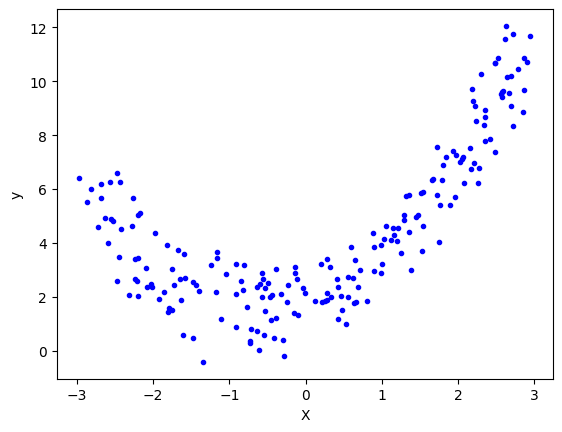

In [15]:
plt.plot(X, y,'b.')
plt.xlabel("X")
plt.ylabel("y")

## **Testing linear regression on our dataset**

In [10]:
# Train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [11]:
# Applying linear regression
lr = LinearRegression()

In [12]:
lr.fit(X_train,y_train)

LinearRegression()

In [13]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

-0.5573412157905477

Text(0, 0.5, 'y')

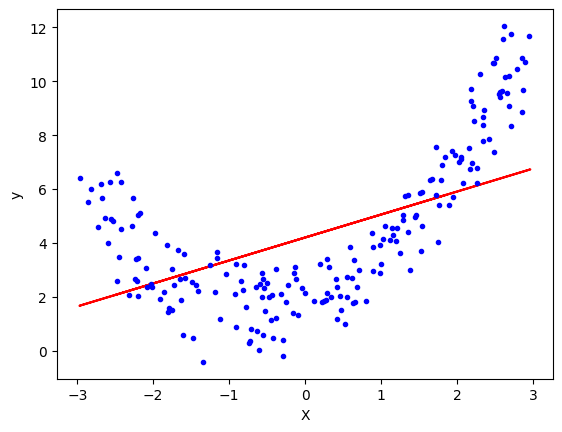

In [16]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")

## **Applying polynomial linear regression**

In [57]:
poly = PolynomialFeatures(degree=6,include_bias=True)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [58]:
print(X_train[0])
print(X_train_trans[0])

[1.84760222]
[ 1.          1.84760222  3.41363398  6.30703773 11.65289693 21.52991827
 39.77872487]


In [59]:
lr = LinearRegression()
lr.fit(X_train_trans,y_train)

LinearRegression()

In [60]:
y_pred = lr.predict(X_test_trans)

In [61]:
r2_score(y_test,y_pred)

0.754554468227616

In [62]:
print(lr.coef_)
print(lr.intercept_)

[[ 0.          0.67484459  0.87083798  0.12466084 -0.03923735 -0.01161731
   0.00408563]]
[1.95425715]


In [63]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

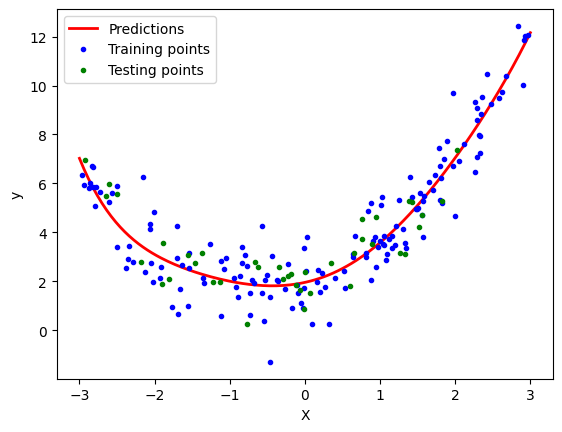

In [64]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## **More than 1 input columns**

In [65]:
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [66]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [67]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

In [68]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))

fig.show()

In [92]:
X_multi = np.array([x,y]).reshape(30,2)
X_multi.shape

ValueError: cannot reshape array of size 200 into shape (30,2)

In [98]:
poly = PolynomialFeatures(degree=20)
X_multi_trans = poly.fit_transform(X_multi)

In [99]:
lr = LinearRegression()
lr.fit(X_multi_trans,z)

LinearRegression()

In [100]:
X_test_multi = poly.transform(final)

In [101]:
z_final = lr.predict(X_multi_trans).reshape(10,10)

In [102]:
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()